In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None) 
pd.set_option('display.max_rows', None)

# 1. Data import

In [5]:
df = pd.read_csv('dataset_latam.csv')

In [6]:
df = df.drop(columns=['Unnamed: 0'])

# 2. Data understanding

In [7]:
df.describe()

,speed_internet,had_sessions_before_quiz,days_since_last_ga_session_asof,quiz_completion_time_seconds,questions_count,amocrm_id,stud_age_amo,age,impressions,link_clicks,spend_usd,visited_tc_7d_target,hour_first_booking_timeslot,gap_lead_to_mk_hours,days_to_mk
count,5557.000000,5458.000000,714.000000,5690.000000,5690.000000,5.690000e+03,5690.000000,5452.000000,5316.000000,5315.000000,5316.000000,5690.000000,5690.000000,5690.000000,5690.000000
mean,3.400158,0.130817,18.271709,767.714014,12.520211,3.957550e+07,10.459227,10.434336,213269.908202,1594.566886,266.558179,0.230756,16.172935,46.370299,1.772408
std,1.521343,0.337231,22.641956,16582.114818,3.244644,2.554566e+05,2.548494,2.565863,172362.642476,923.330311,107.305126,0.421353,7.356811,359.733771,14.985833
min,0.000000,0.000000,1.000000,0.000000,1.000000,3.553915e+07,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14003.000000,-583.000000
25%,2.520000,0.000000,2.000000,80.955500,13.000000,3.940116e+07,9.000000,8.000000,99061.000000,1003.000000,200.229656,0.000000,16.000000,18.000000,1.000000
50%,3.340000,0.000000,8.500000,107.511500,13.000000,3.959898e+07,10.000000,10.000000,163296.000000,1426.000000,255.960538,0.000000,19.000000,40.000000,2.000000
75%,4.250000,0.000000,24.000000,151.185000,13.000000,3.975029e+07,12.000000,12.000000,274764.000000,2159.000000,335.230820,0.000000,21.000000,78.000000,3.000000
max,21.920000,1.000000,92.000000,688280.135000,53.000000,3.993136e+07,17.000000,17.000000,910885.000000,4761.000000,655.524698,1.000000,23.000000,1833.000000,76.000000


In [8]:
df.dtypes

first_booking_timeslot              object
last_booking_timeslot               object
speed_internet                     float64
had_sessions_before_quiz           float64
days_since_last_ga_session_asof    float64
time_started                        object
time_end                            object
quiz_completion_time_seconds       float64
questions_count                      int64
os_device                           object
device_type                         object
brand_device                        object
country                             object
amocrm_id                            int64
source                              object
utm_marketing                       object
last_booking_status                 object
stud_age_amo                         int64
marketing_course_global             object
device_type_ui                      object
utm_referrer                        object
monthly_budget                      object
extracurricular_spend               object
respondent 

Duplicates

In [9]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}  ({n_dup / len(df):.2%})")

Duplicate rows: 0  (0.00%)


Type conversions

In [10]:
date_cols = ["first_booking_timeslot", "last_booking_timeslot", "time_started",
             "time_end"]

df[date_cols] = df[date_cols].apply(
    pd.to_datetime,
    errors="coerce"
)

Translate day-of-week columns to English

In [11]:
day_of_week_map = {
    "понедельник": "Monday",
    "вторник": "Tuesday",
    "среда": "Wednesday",
    "четверг": "Thursday",
    "пятница": "Friday",
    "суббота": "Saturday",
    "воскресенье": "Sunday",
}

day_of_week_cols = ["day_of_week_tc", "day_of_week_quiz_start"]
df[day_of_week_cols] = df[day_of_week_cols].replace(day_of_week_map)

df[day_of_week_cols].head()

,day_of_week_tc,day_of_week_quiz_start
0,Thursday,Thursday
1,Tuesday,Sunday
2,Monday,Friday
3,Wednesday,Tuesday
4,Tuesday,Saturday


In [12]:
cat_cols = [
    "os_device",
    "device_type",
    "brand_device",
    "country",
    "source",
    "utm_marketing",
    "last_booking_status",
    "marketing_course_global",
    "device_type_ui",
    "utm_referrer",
    "monthly_budget",
    "extracurricular_spend",
    "respondent",
    "took_online_classes_before",
    "reaction_to_trial_class",
    "gender",
    "decision_responsibility",
    "free_time",
    "internet_stability",
    "would_pay_if_useful",
    "has_computer",
    "utm_content",
    "utm_campaign",
    "utm_medium",
    "utm_source",
    "region",
    "campaign_event_empiric",
    "ad_back_empiric",
    "ad_group_product",
    "ad_hero_dynamic_empiric",
    "ad_product_empiric",
    "creative_call_to_action_type",
    "campaign_offer_empiric",
    "campaign_bid_strategy_empiric",
    "course_global",
    "format",
    "creative_concept",
    "landing_id",
    "product_offer_empiric",
    "creative_uvp",
    "day_of_week_tc",
    "day_of_week_quiz_start",
]
df[cat_cols] = df[cat_cols].astype("category")

In [13]:
df["visited_tc_7d_target"] = df["visited_tc_7d_target"].astype(int)

Missing values

In [14]:
df.isna().mean().sort_values(ascending=False)

creative_call_to_action_type       0.999297
ad_back_empiric                    0.961687
ad_hero_dynamic_empiric            0.955360
creative_concept                   0.882601
ad_group_product                   0.876977
days_since_last_ga_session_asof    0.874517
creative_uvp                       0.870475
ad_product_empiric                 0.869772
landing_id                         0.869772
format                             0.869772
utm_content                        0.843409
respondent                         0.073286
monthly_budget                     0.066432
link_clicks                        0.065905
impressions                        0.065729
spend_usd                          0.065729
would_pay_if_useful                0.065378
gender                             0.064851
extracurricular_spend              0.064675
has_computer                       0.064148
internet_stability                 0.063796
free_time                          0.063620
decision_responsibility         

Cardinality check

In [15]:
df[cat_cols].nunique().sort_values(ascending=False)

utm_referrer                     5277
utm_marketing                     196
utm_content                       188
utm_campaign                      120
os_device                          83
country                            31
ad_hero_dynamic_empiric            24
landing_id                         18
creative_concept                   18
utm_medium                         17
brand_device                       15
product_offer_empiric              14
creative_uvp                       13
utm_source                         12
source                             12
ad_product_empiric                  9
ad_back_empiric                     9
region                              8
day_of_week_quiz_start              7
day_of_week_tc                      7
campaign_bid_strategy_empiric       6
ad_group_product                    6
format                              5
reaction_to_trial_class             4
course_global                       4
free_time                           4
marketing_co

Target distribution (total visited tc vs not-visited)

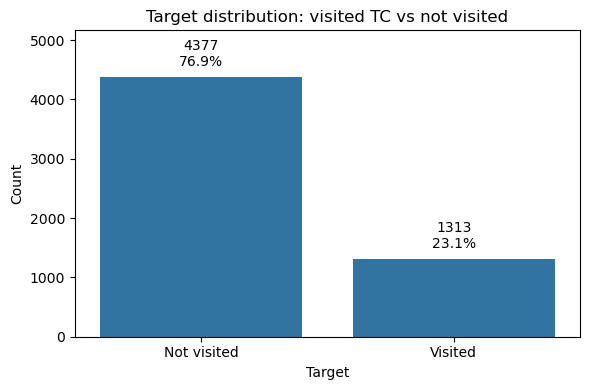

In [16]:
target_col = "visited_tc_7d_target"

target_counts = df[target_col].value_counts().sort_index()
target_share = df[target_col].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values
)

max_count = target_counts.max()
ax.set_ylim(0, max_count * 1.18)

for i, count in enumerate(target_counts.values):
    pct = target_share.iloc[i]
    ax.text(
        i,
        count + max_count * 0.03,
        f"{count}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Target distribution: visited TC vs not visited")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1],
    labels=["Not visited", "Visited"]
)

plt.tight_layout()
plt.show()

## Categorical feature histograms

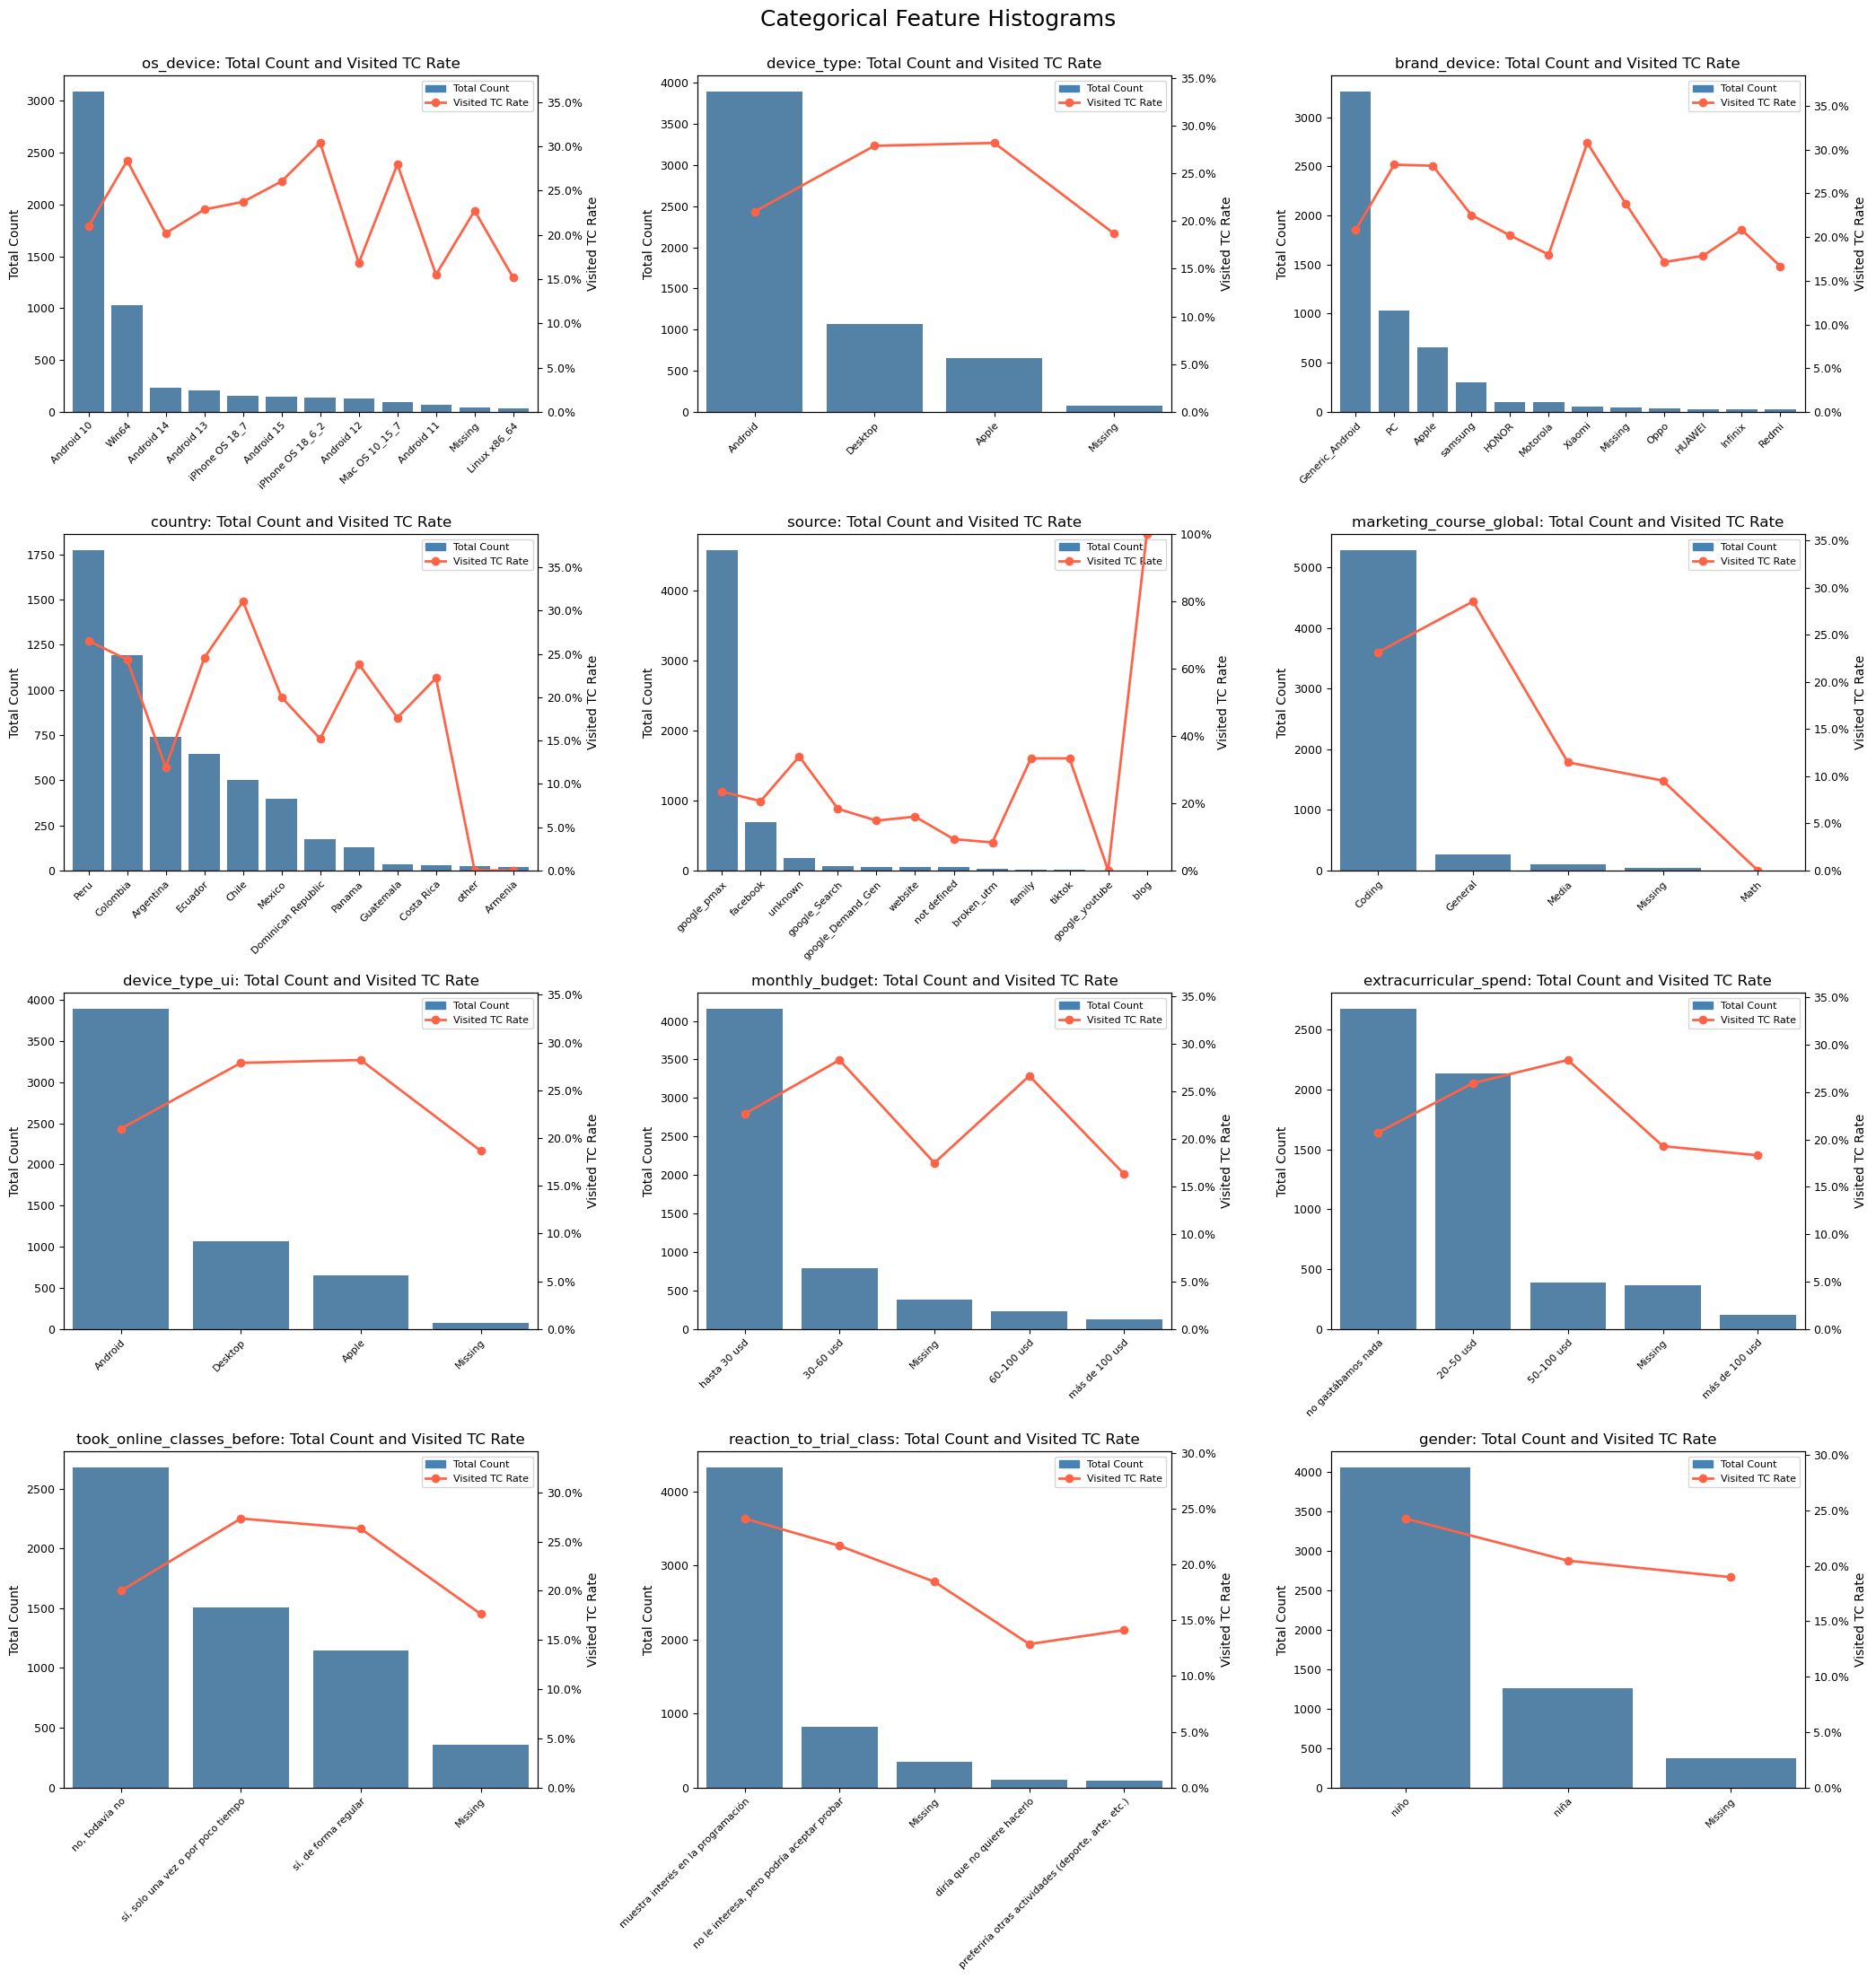

In [17]:
target_col = "visited_tc_7d_target"

excluded_cat_cols = [
    "utm_referrer",
    "utm_marketing",
    "last_booking_status",
    "respondent",
    "utm_content",
    "utm_medium",
    "region",
    "landing_id",
]

cat_cols = [
    "os_device",
    "device_type",
    "brand_device",
    "country",
    "source",
    "utm_marketing",
    "last_booking_status",
    "marketing_course_global",
    "device_type_ui",
    "utm_referrer",
    "monthly_budget",
    "extracurricular_spend",
    "respondent",
    "took_online_classes_before",
    "reaction_to_trial_class",
    "gender",
    "decision_responsibility",
    "free_time",
    "internet_stability",
    "would_pay_if_useful",
    "has_computer",
    "utm_content",
    "utm_campaign",
    "utm_medium",
    "utm_source",
    "region",
    "campaign_event_empiric",
    "ad_back_empiric",
    "ad_group_product",
    "ad_hero_dynamic_empiric",
    "ad_product_empiric",
    "creative_call_to_action_type",
    "campaign_offer_empiric",
    "campaign_bid_strategy_empiric",
    "course_global",
    "format",
    "creative_concept",
    "landing_id",
    "product_offer_empiric",
    "creative_uvp",
    "day_of_week_tc",
    "day_of_week_quiz_start",
]

cat_cols = [col for col in cat_cols if col not in excluded_cat_cols and col in df.columns]

top_n = 12
ncols = 3
max_rows = 4
cat_cols = cat_cols[: ncols * max_rows]
nrows = (len(cat_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax1 = axes[i]
    tmp = df[[col, target_col]].copy()
    tmp[col] = tmp[col].astype("object").fillna("Missing")

    top_categories = tmp[col].value_counts().head(top_n).index
    tmp = tmp[tmp[col].isin(top_categories)]

    plot_df = (
        tmp.groupby(col, observed=False)
        .agg(
            total_count=(target_col, "size"),
            visited_rate=(target_col, "mean")
        )
        .reset_index()
        .sort_values("total_count", ascending=False)
    )

    plot_df[col] = plot_df[col].astype(str)

    sns.barplot(
        data=plot_df,
        x=col,
        y="total_count",
        ax=ax1,
        color="steelblue"
    )

    ax1.set_title(f"{col}: Total Count and Visited TC Rate", fontsize=12)
    ax1.set_xlabel("")
    ax1.set_ylabel("Total Count", color="black")
    ax1.tick_params(axis="y", labelcolor="black", labelsize=9)
    ax1.tick_params(axis="x", labelsize=8, rotation=45)

    for label in ax1.get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")

    ax2 = ax1.twinx()

    ax2.plot(
        range(len(plot_df)),
        plot_df["visited_rate"],
        color="tomato",
        marker="o",
        linewidth=2,
        label="Visited TC Rate"
    )

    ax2.set_ylabel("Visited TC Rate", color="black")
    ax2.tick_params(axis="y", labelcolor="black", labelsize=9)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax1.margins(x=0.02)
    ax2.set_ylim(0, min(1, plot_df["visited_rate"].max() * 1.25))

    bar_patch = plt.Rectangle((0, 0), 1, 1, color="steelblue")
    line_patch = plt.Line2D(
        [0],
        [0],
        color="tomato",
        marker="o",
        linewidth=2
    )

    ax1.legend(
        [bar_patch, line_patch],
        ["Total Count", "Visited TC Rate"],
        loc="upper right",
        fontsize=8
    )

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Histograms", fontsize=18, y=1.0)
fig.tight_layout()
fig.savefig("categorical_feature_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Target share by categorical values

In [18]:
target_col = "visited_tc_7d_target"

def target_share_by_category(df, col, target_col=target_col, top_n=None, min_count=0):
    tmp = df[[col, target_col]].copy()
    tmp[col] = tmp[col].astype("object").fillna("Missing")

    summary = (
        tmp.groupby(col, observed=False)
        .agg(
            total_count=(target_col, "size"),
            target_count=(target_col, "sum"),
            visited_rate=(target_col, "mean"),
        )
        .reset_index()
        .sort_values("total_count", ascending=False)
    )

    summary["observation_share_pct"] = summary["total_count"].div(len(tmp)).mul(100)
    summary["visited_rate_pct"] = summary["visited_rate"].mul(100)
    summary = summary.drop(columns="visited_rate")
    summary[col] = summary[col].astype(str)
    summary = summary.rename(columns={col: "category"})
    summary.insert(0, "feature", col)

    if min_count:
        summary = summary[summary["total_count"] >= min_count]
    if top_n is not None:
        summary = summary.head(top_n)

    return summary[
        ["feature", "category", "total_count", "observation_share_pct", "target_count", "visited_rate_pct"]
    ].round({"observation_share_pct": 2, "visited_rate_pct": 2})


geo_source_cols = ["country", "source"]
readiness_intent_cols = [
    "internet_stability",
    "has_computer",
    "would_pay_if_useful",
    "monthly_budget",
    "extracurricular_spend",
]

geo_source_target_summary = pd.concat(
    [target_share_by_category(df, col, top_n=12) for col in geo_source_cols if col in df.columns],
    ignore_index=True,
)

readiness_intent_target_summary = pd.concat(
    [target_share_by_category(df, col) for col in readiness_intent_cols if col in df.columns],
    ignore_index=True,
)

display(geo_source_target_summary)
display(readiness_intent_target_summary)

,feature,category,total_count,observation_share_pct,target_count,visited_rate_pct
0,country,Peru,1773,31.16,470,26.51
1,country,Colombia,1191,20.93,290,24.35
2,country,Argentina,740,13.01,88,11.89
3,country,Ecuador,647,11.37,159,24.57
4,country,Chile,499,8.77,155,31.06
5,country,Mexico,395,6.94,79,20.00
6,country,Dominican Republic,171,3.01,26,15.20
7,country,Panama,130,2.28,31,23.85
8,country,Guatemala,34,0.60,6,17.65
9,country,Costa Rica,27,0.47,6,22.22


,feature,category,total_count,observation_share_pct,target_count,visited_rate_pct
0,internet_stability,es estable,4451,78.22,1131,25.41
1,internet_stability,a veces se interrumpe,809,14.22,108,13.35
2,internet_stability,Missing,363,6.38,68,18.73
3,internet_stability,se interrumpe con frecuencia,67,1.18,6,8.96
4,has_computer,"sí, computadora o laptop",4293,75.45,1134,26.42
5,has_computer,solo teléfono o tablet,1032,18.14,106,10.27
6,has_computer,Missing,365,6.41,73,20.00
7,would_pay_if_useful,"sí, lo estamos contemplando",2002,35.18,535,26.72
8,would_pay_if_useful,solo si el precio es razonable,1965,34.53,459,23.36
9,would_pay_if_useful,"no estamos seguros, necesitamos más información",1073,18.86,218,20.32


## Box plot diagrams

In [19]:
def plot_delay_boxplots(df, cols, ncols=2):
    if not cols:
        return

    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6 * nrows), squeeze=False)
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(
            data=df, x="visited_tc_7d_target", y=col, ax=axes[i],
            hue="visited_tc_7d_target", palette=["steelblue", "tomato"],
            showfliers=False,
            flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
            legend=False,
        )
        axes[i].set_title(col, fontsize=17)
        axes[i].set_xlabel("1 = Visited TC  |  0 = Not Visited TC", fontsize=14)
        axes[i].tick_params(labelsize=14)
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Feature Distributions: Visited TC vs Not Visited TC", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

In [20]:
cat_cols = df.select_dtypes(include=["float64", "int64"]).columns.to_list()

In [21]:
cat_cols

['speed_internet',
 'had_sessions_before_quiz',
 'days_since_last_ga_session_asof',
 'quiz_completion_time_seconds',
 'questions_count',
 'amocrm_id',
 'stud_age_amo',
 'age',
 'impressions',
 'link_clicks',
 'spend_usd',
 'visited_tc_7d_target',
 'hour_first_booking_timeslot',
 'gap_lead_to_mk_hours',
 'days_to_mk']

In [22]:
cat_cols.remove('amocrm_id')
cat_cols.remove('questions_count')
cat_cols.remove('had_sessions_before_quiz')
cat_cols.remove('visited_tc_7d_target')

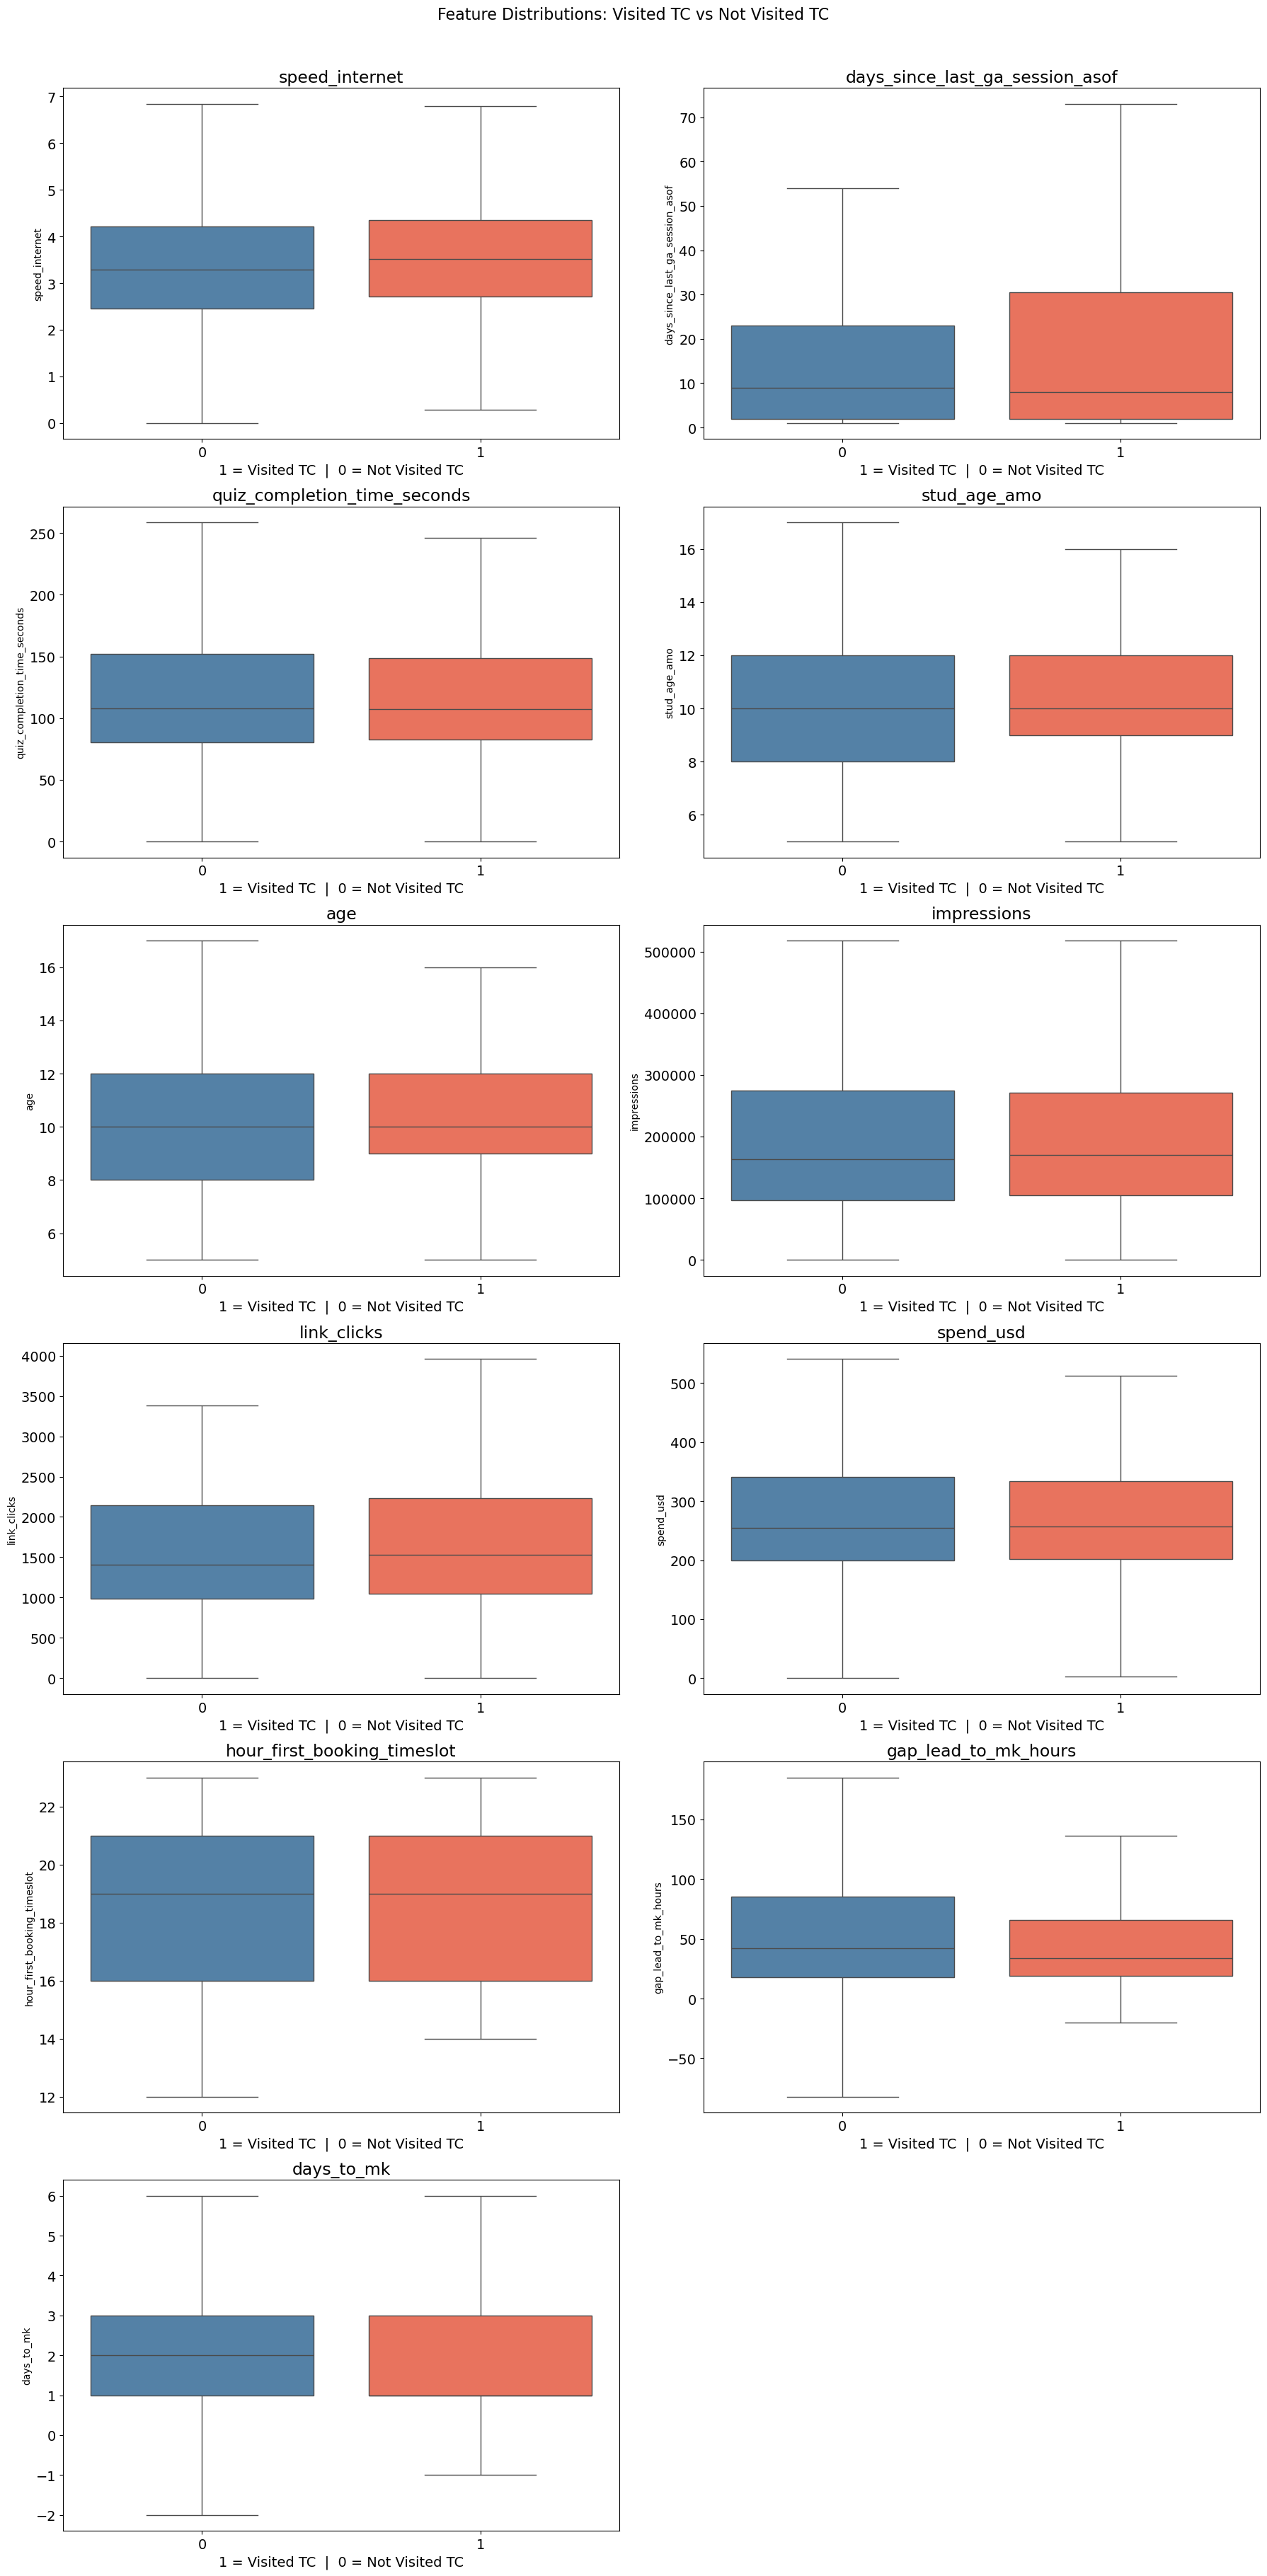

In [23]:
plot_delay_boxplots(df, cat_cols, ncols=2)

## Missing values

In [24]:
missing = df.isnull().sum()
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print("No NaN values found in any column.")
else:
    print(missing_nonzero)

speed_internet                      133
had_sessions_before_quiz            232
days_since_last_ga_session_asof    4976
os_device                            44
device_type                          75
brand_device                         42
utm_marketing                        44
marketing_course_global              42
device_type_ui                       75
utm_referrer                          4
monthly_budget                      378
extracurricular_spend               368
respondent                          417
took_online_classes_before          357
reaction_to_trial_class             352
age                                 238
gender                              369
decision_responsibility             361
free_time                           362
internet_stability                  363
would_pay_if_useful                 372
has_computer                        365
utm_content                        4799
utm_campaign                         61
utm_medium                           60


In [25]:
missing_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

missing_percent

creative_call_to_action_type       99.93
ad_back_empiric                    96.17
ad_hero_dynamic_empiric            95.54
creative_concept                   88.26
ad_group_product                   87.70
days_since_last_ga_session_asof    87.45
creative_uvp                       87.05
ad_product_empiric                 86.98
landing_id                         86.98
format                             86.98
utm_content                        84.34
respondent                          7.33
monthly_budget                      6.64
link_clicks                         6.59
impressions                         6.57
spend_usd                           6.57
would_pay_if_useful                 6.54
gender                              6.49
extracurricular_spend               6.47
has_computer                        6.41
internet_stability                  6.38
free_time                           6.36
decision_responsibility             6.34
took_online_classes_before          6.27
reaction_to_tria

# 3. Data Quality

Missing values by target

In [26]:
missing_by_target = (
    df.groupby(target_col, observed=False)
      .apply(lambda x: x.isna().mean().mul(100))
      .T
      .rename(columns={0: "not_visited_missing_pct", 1: "visited_missing_pct"})
)

for col in ["not_visited_missing_pct", "visited_missing_pct"]:
    if col not in missing_by_target.columns:
        missing_by_target[col] = 0

missing_by_target["abs_diff_pct_points"] = (
    missing_by_target["visited_missing_pct"] - missing_by_target["not_visited_missing_pct"]
).abs()

missing_by_target = missing_by_target.sort_values("abs_diff_pct_points", ascending=False).round(2)
missing_by_target.head(20)

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_32901/2588059042.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(target_col, observed=False)


visited_tc_7d_target,not_visited_missing_pct,visited_missing_pct,abs_diff_pct_points
utm_content,83.80,86.14,2.34
monthly_budget,7.13,5.03,2.10
took_online_classes_before,6.72,4.80,1.92
ad_product_empiric,86.54,88.42,1.88
format,86.54,88.42,1.88
landing_id,86.54,88.42,1.88
free_time,6.79,4.95,1.83
creative_uvp,86.63,88.42,1.79
decision_responsibility,6.74,5.03,1.71
creative_concept,87.87,89.57,1.70


Date and time sanity checks

In [27]:
date_quality = pd.DataFrame({
    "missing_count": df[date_cols].isna().sum(),
    "missing_pct": df[date_cols].isna().mean().mul(100).round(2),
    "min": df[date_cols].min(),
    "max": df[date_cols].max(),
})

date_quality

,missing_count,missing_pct,min,max
first_booking_timeslot,0,0.0,2024-04-19 00:00:00.000,2026-03-18 23:00:00.000
last_booking_timeslot,0,0.0,2024-04-19 00:00:00.000,2026-03-18 23:00:00.000
time_started,0,0.0,2025-10-27 12:34:53.763,2026-03-12 15:40:58.603
time_end,0,0.0,2025-10-27 12:35:01.863,2026-03-12 15:43:11.113


In [28]:
time_checks = pd.Series({
    "quiz_end_before_start": (df["time_end"] < df["time_started"]).sum(),
    "last_booking_before_first_booking": (df["last_booking_timeslot"] < df["first_booking_timeslot"]).sum(),
    "trial_class_before_quiz_start": (df["first_booking_timeslot"] < df["time_started"]).sum(),
    "negative_gap_lead_to_mk_hours": (df["gap_lead_to_mk_hours"] < 0).sum(),
    "negative_days_to_mk": (df["days_to_mk"] < 0).sum(),
})

pd.DataFrame({
    "count": time_checks,
    "share_pct": (time_checks / len(df) * 100).round(2),
})

,count,share_pct
quiz_end_before_start,0,0.00
last_booking_before_first_booking,0,0.00
trial_class_before_quiz_start,107,1.88
negative_gap_lead_to_mk_hours,98,1.72
negative_days_to_mk,92,1.62


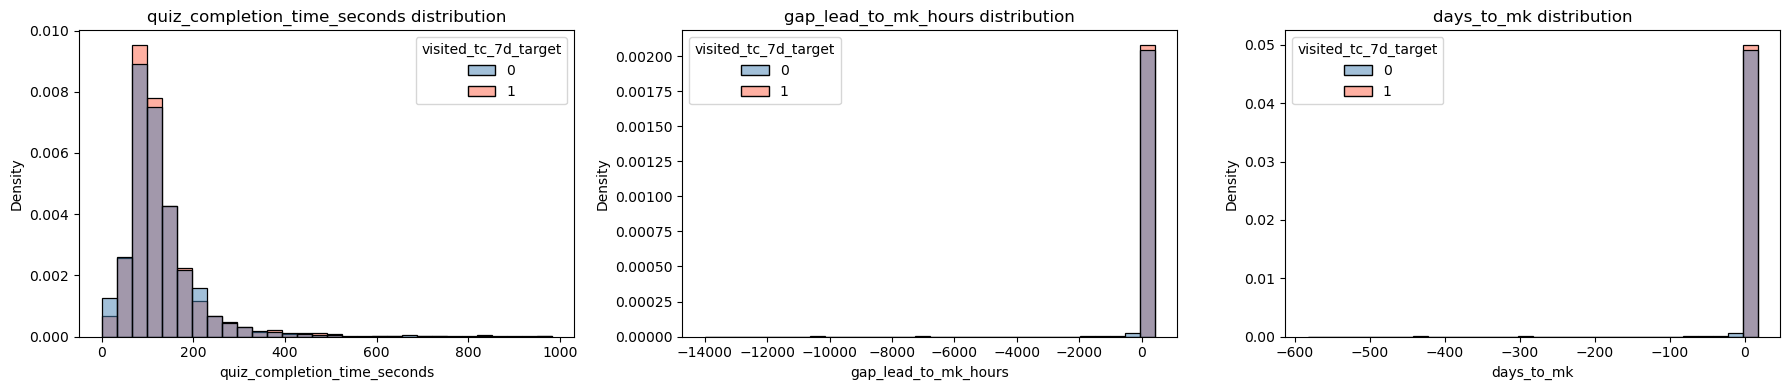

In [29]:
time_plot_cols = ["quiz_completion_time_seconds", "gap_lead_to_mk_hours", "days_to_mk"]
time_plot_cols = [col for col in time_plot_cols if col in df.columns]

fig, axes = plt.subplots(1, len(time_plot_cols), figsize=(6 * len(time_plot_cols), 4), squeeze=False)

for ax, col in zip(axes.flatten(), time_plot_cols):
    upper = df[col].quantile(0.99)
    sns.histplot(
        data=df[df[col].between(df[col].min(), upper)],
        x=col,
        hue=target_col,
        bins=30,
        stat="density",
        common_norm=False,
        palette=["steelblue", "tomato"],
        ax=ax,
    )
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

Numeric sanity checks

In [30]:
non_negative_cols = [
    "speed_internet",
    "had_sessions_before_quiz",
    "days_since_last_ga_session_asof",
    "quiz_completion_time_seconds",
    "questions_count",
    "stud_age_amo",
    "age",
    "impressions",
    "link_clicks",
    "spend_usd",
    "hour_first_booking_timeslot",
    "gap_lead_to_mk_hours",
    "days_to_mk",
]
non_negative_cols = [col for col in non_negative_cols if col in df.columns]

sanity_rows = []
for col in non_negative_cols:
    sanity_rows.append({
        "column": col,
        "missing": df[col].isna().sum(),
        "negative": (df[col] < 0).sum(),
        "zero": (df[col] == 0).sum(),
        "min": df[col].min(),
        "median": df[col].median(),
        "max": df[col].max(),
    })

numeric_sanity = pd.DataFrame(sanity_rows).set_index("column")
numeric_sanity

,missing,negative,zero,min,median,max
column,,,,,,
speed_internet,133,0,2,0.0,3.340000,21.920000
had_sessions_before_quiz,232,0,4744,0.0,0.000000,1.000000
days_since_last_ga_session_asof,4976,0,0,1.0,8.500000,92.000000
quiz_completion_time_seconds,0,0,116,0.0,107.511500,688280.135000
questions_count,0,0,0,1.0,13.000000,53.000000
stud_age_amo,0,0,0,5.0,10.000000,17.000000
age,238,0,0,5.0,10.000000,17.000000
impressions,374,0,1,0.0,163296.000000,910885.000000
link_clicks,375,0,3,0.0,1426.000000,4761.000000


Outlier inspection with the IQR rule

In [31]:
outlier_cols = [
    "speed_internet",
    "quiz_completion_time_seconds",
    "age",
    "stud_age_amo",
    "impressions",
    "link_clicks",
    "spend_usd",
    "gap_lead_to_mk_hours",
    "days_to_mk",
]
outlier_cols = [col for col in outlier_cols if col in df.columns]

outlier_rows = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct": mask.mean() * 100,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
      .set_index("column")
      .sort_values("outlier_pct", ascending=False)
      .round(2)
)

outlier_summary

,lower_bound,upper_bound,outlier_count,outlier_pct
column,,,,
days_to_mk,-2.00,6.00,484,8.51
gap_lead_to_mk_hours,-72.00,168.00,427,7.50
quiz_completion_time_seconds,-24.39,256.53,370,6.50
impressions,-164493.50,538318.50,329,5.78
link_clicks,-731.00,3893.00,180,3.16
speed_internet,-0.07,6.84,114,2.00
stud_age_amo,4.50,16.50,93,1.63
spend_usd,-2.27,537.73,45,0.79
age,2.00,18.00,0,0.00


Categorical cardinality and rare categories

In [32]:
categorical_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

cardinality = (
    pd.DataFrame({
        "unique_values": df[categorical_cols].nunique(dropna=False),
        "missing_pct": df[categorical_cols].isna().mean().mul(100),
        "most_frequent_share_pct": [df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100 for col in categorical_cols],
        "sample_values": [df[col].astype("object").fillna("Missing").value_counts().index[:3].tolist() for col in categorical_cols],
    })
    .sort_values("unique_values", ascending=False)
    .round(2)
)

cardinality.head(20)

,unique_values,missing_pct,most_frequent_share_pct,sample_values
utm_referrer,5278,0.07,0.65,"[?segment=14&ifHideHeader=true&success_page=standart&utm_source=website, ?segment=14, ?segment=14&date_start=0&date_end=14&accountid=4879293609&utm_source=google_pmax&utm_medium=cpc&utm_campaign=23174074053&adgroup=&utm_term=&utm_content=&gad_source=2&gad_campaignid=23179368224&ab_redirected=true]"
utm_marketing,197,0.77,32.93,"[23303683895, 23174074053, 23527299808]"
utm_content,189,84.34,84.34,"[Missing, 120233271193560424, 120233271193570424]"
utm_campaign,121,1.07,33.11,"[23303683895, 23174074053, 23527299808]"
os_device,84,0.77,54.25,"[Android 10, Win64, Android 14]"
country,31,0.00,31.16,"[Peru, Colombia, Argentina]"
ad_hero_dynamic_empiric,25,95.54,95.54,"[Missing, RobloxTeam, Mix]"
landing_id,19,86.98,86.98,"[Missing, LatQuScoG2, LatAuFreeTC]"
creative_concept,19,88.26,88.26,"[Missing, Background, Characters]"
utm_medium,18,1.05,82.95,"[cpc, Facebook_Mobile_Feed, email]"


Correlation with target for numerical attributes

In [33]:
numeric_corr = (
    df.select_dtypes(include="number")
      .corr(numeric_only=True)[target_col]
      .drop(target_col)
      .sort_values(key=lambda x: x.abs(), ascending=False)
)

numeric_corr.head(20)

days_since_last_ga_session_asof    0.050099
speed_internet                     0.048312
amocrm_id                          0.029224
link_clicks                        0.023087
age                               -0.018195
stud_age_amo                      -0.015218
quiz_completion_time_seconds      -0.011165
hour_first_booking_timeslot        0.007141
impressions                       -0.005608
spend_usd                         -0.003269
questions_count                   -0.002190
had_sessions_before_quiz          -0.000564
days_to_mk                        -0.000144
gap_lead_to_mk_hours              -0.000136
Name: visited_tc_7d_target, dtype: float64

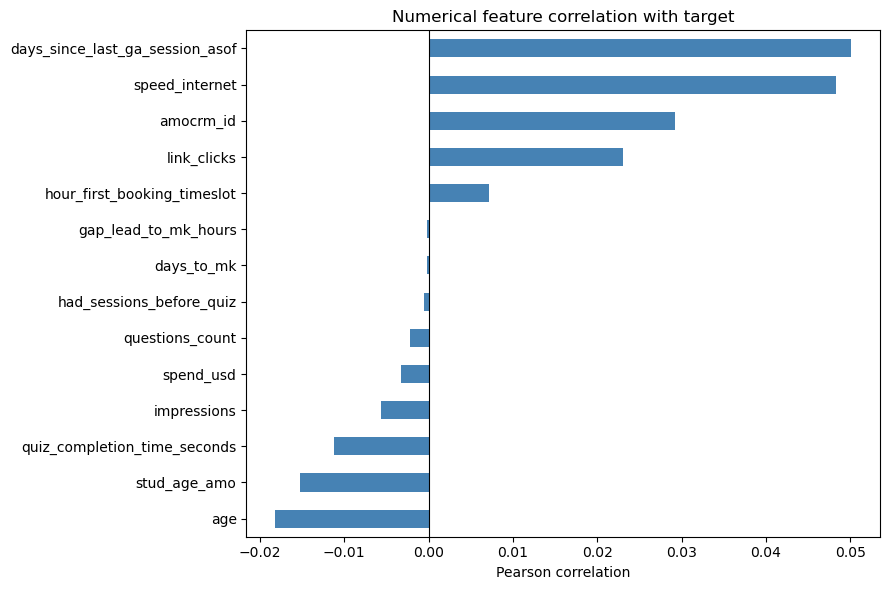

In [34]:
top_corr = numeric_corr.head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_corr.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Numerical feature correlation with target")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 4. Data preprocessing